# **Compute the SPI**

In [1]:
# Add SPI src directory to Python path 
import sys
sys.path.insert(0, '../src') 

# Core libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime

# Import SPI functions
from indices import (  #SPI and SPEI climate indices calculation module
    spi,
    spi_multi_scale,
    save_fitting_params,
    load_fitting_params,
    save_index_to_netcdf,
    classify_drought,
    get_drought_area_percentage
)
 # Configuration module for SPI/SPEI climate indices calculation
from config import Periodicity # MOnthly or daily

# Plotting settings
plt.rcParams['figure.figsize'] = (20, 10)
plt.rcParams['font.size'] = 12

print("✓ All imports successful!")

✓ All imports successful!


## **Configurations**

In [2]:
# File paths
precip_file = '../data/processed/chirps/chirps_mozambique.nc'

# Variable name
precip_var = 'precip'

# Calibration period (WMO standard: 1991-2020)
calib_start = 1991
calib_end = 2020

# Output directory
output_dir = '../output/netcdf/'

print("Configuration:")
print(f"  Precipitation file: {precip_file}")
print(f"  Variable: {precip_var}")
print(f"  Calibration period: {calib_start}-{calib_end}")

Configuration:
  Precipitation file: ../data/processed/chirps/chirps_mozambique.nc
  Variable: precip
  Calibration period: 1991-2020


## **Load Precipitation Data**

In [3]:
# Load the Precipitation
ds = xr.open_dataset(precip_file)
precip = ds[precip_var]


print("✓ Data loaded successfully!")
print(f"\nDataset Information:")
print(f"  Shape: {precip.shape}")
print(f"  Dimensions: {precip.dims}")
print(f"  Time range: {precip.time[0].values} to {precip.time[-1].values}")
print(f"  Lat range: {float(precip.lat.min()):.2f}° to {float(precip.lat.max()):.2f}°")
print(f"  Lon range: {float(precip.lon.min()):.2f}° to {float(precip.lon.max()):.2f}°")
print(f"\nStatistics:")
print(f"  Mean: {float(precip.mean()):.1f} mm/month")
print(f"  Min: {float(precip.min()):.1f} mm/month")
print(f"  Max: {float(precip.max()):.1f} mm/month")
print(f"  Zero values: {int((precip == 0).sum())} ({100 * float((precip == 0).sum() / precip.size):.1f}%)")

✓ Data loaded successfully!

Dataset Information:
  Shape: (541, 329, 213)
  Dimensions: ('time', 'lat', 'lon')
  Time range: 1981-01-01T00:00:00.000000000 to 2026-01-01T00:00:00.000000000
  Lat range: -26.88° to -10.48°
  Lon range: 30.23° to 40.83°

Statistics:
  Mean: 91.6 mm/month
  Min: 0.0 mm/month
  Max: 1292.7 mm/month
  Zero values: 5037 (0.0%)


## **Visualize Precipitation Data**

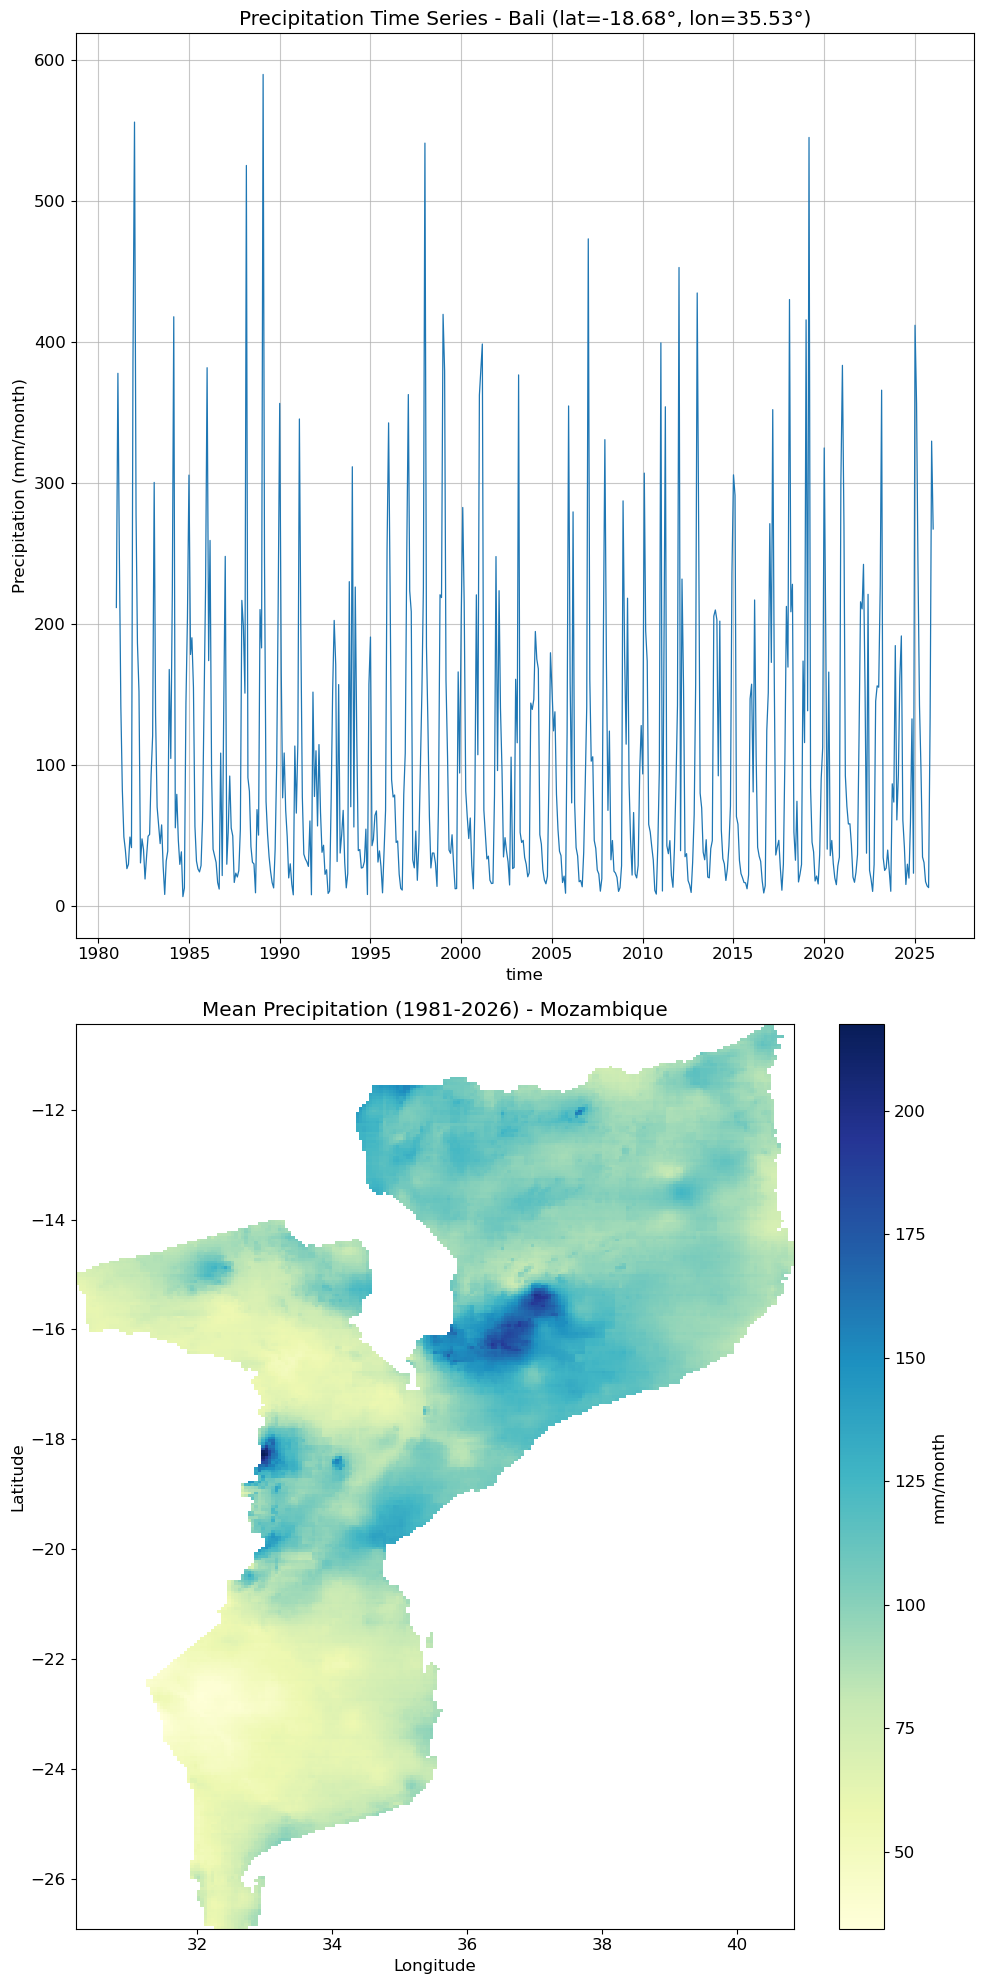

In [11]:
# Select a sample location (center Of MOZ)
sample_lat_idx = len(precip.lat) // 2
sample_lon_idx = len(precip.lon) // 2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 20))

# Time series at sample point
precip[:, sample_lat_idx, sample_lon_idx].plot(ax=ax1, linewidth=0.9)
ax1.set_title(f'Precipitation Time Series - Bali (lat={float(precip.lat[sample_lat_idx]):.2f}°, lon={float(precip.lon[sample_lon_idx]):.2f}°)')
ax1.set_ylabel('Precipitation (mm/month)')
ax1.grid(True, alpha=0.7)

# Spatial pattern (mean over tine)
precip.mean(dim='time').plot(ax=ax2, cmap='YlGnBu', cbar_kwargs={'label': 'mm/month'})
ax2.set_title('Mean Precipitation (1981-2026) - Mozambique')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

## **Calculate SPI for a single time scale**

In [12]:
# Let's calculate SPI-12 (12-month accumulation period) for long-term water resources monitoring
print("Calculating SPI-12...")
# each month will have their SPi on the 12 months scale
spi_12, params = spi(
    precip,
    scale=12, # accumulation scale (e.g., 1, 3, 6, 12 months)
    periodicity='monthly', # monthly or daily
    calibration_start_year=calib_start,
    calibration_end_year=calib_end,
    return_params=True  # Return fitting parameters for saving
)

print("✓ SPI-12 calculation complete!")
print(f"\nOutput Information:")
print(f"  Shape: {spi_12.shape}")
print(f"  Valid range: [{float(spi_12.min()):.2f}, {float(spi_12.max()):.2f}]")
print(f"  Mean: {float(spi_12.mean()):.3f}")
print(f"  Std: {float(spi_12.std()):.3f}")
print(f"  NaN values: {int(np.isnan(spi_12).sum())} ({100 * float(np.isnan(spi_12).sum() / spi_12.size):.1f}%)")

2026-03-16 22:31:02 | INFO     | indices | Computing SPI-12 (distribution=gamma)
2026-03-16 22:31:02 | INFO     | indices | Input shape: (541, 329, 213), dims: ('time', 'lat', 'lon'), data_start_year: 1981
2026-03-16 22:31:02 | INFO     | compute | Computing index: shape=(541, 329, 213), scale=12, distribution=gamma, grid_cells=70,077
2026-03-16 22:31:02 | INFO     | compute | Data has 541 timesteps (not divisible by 12). Padding 11 NaN timesteps to complete final year (46 years total).
2026-03-16 22:31:02 | INFO     | compute | Step 1/3: Applying temporal scaling...


Calculating SPI-12...


2026-03-16 22:31:03 | INFO     | compute | Step 2/3: Computing gamma parameters...
2026-03-16 22:31:03 | INFO     | compute | Step 3/3: Transforming to standard normal...
2026-03-16 22:31:08 | INFO     | compute | Index computation complete
2026-03-16 22:31:09 | INFO     | indices | SPI-12 computation complete. Output shape: (541, 329, 213)


✓ SPI-12 calculation complete!

Output Information:
  Shape: (541, 329, 213)
  Valid range: [-3.09, 3.09]
  Mean: 0.016
  Std: 1.015
  NaN values: 23206807 (61.2%)


## **Visualize SPI-12 Results**

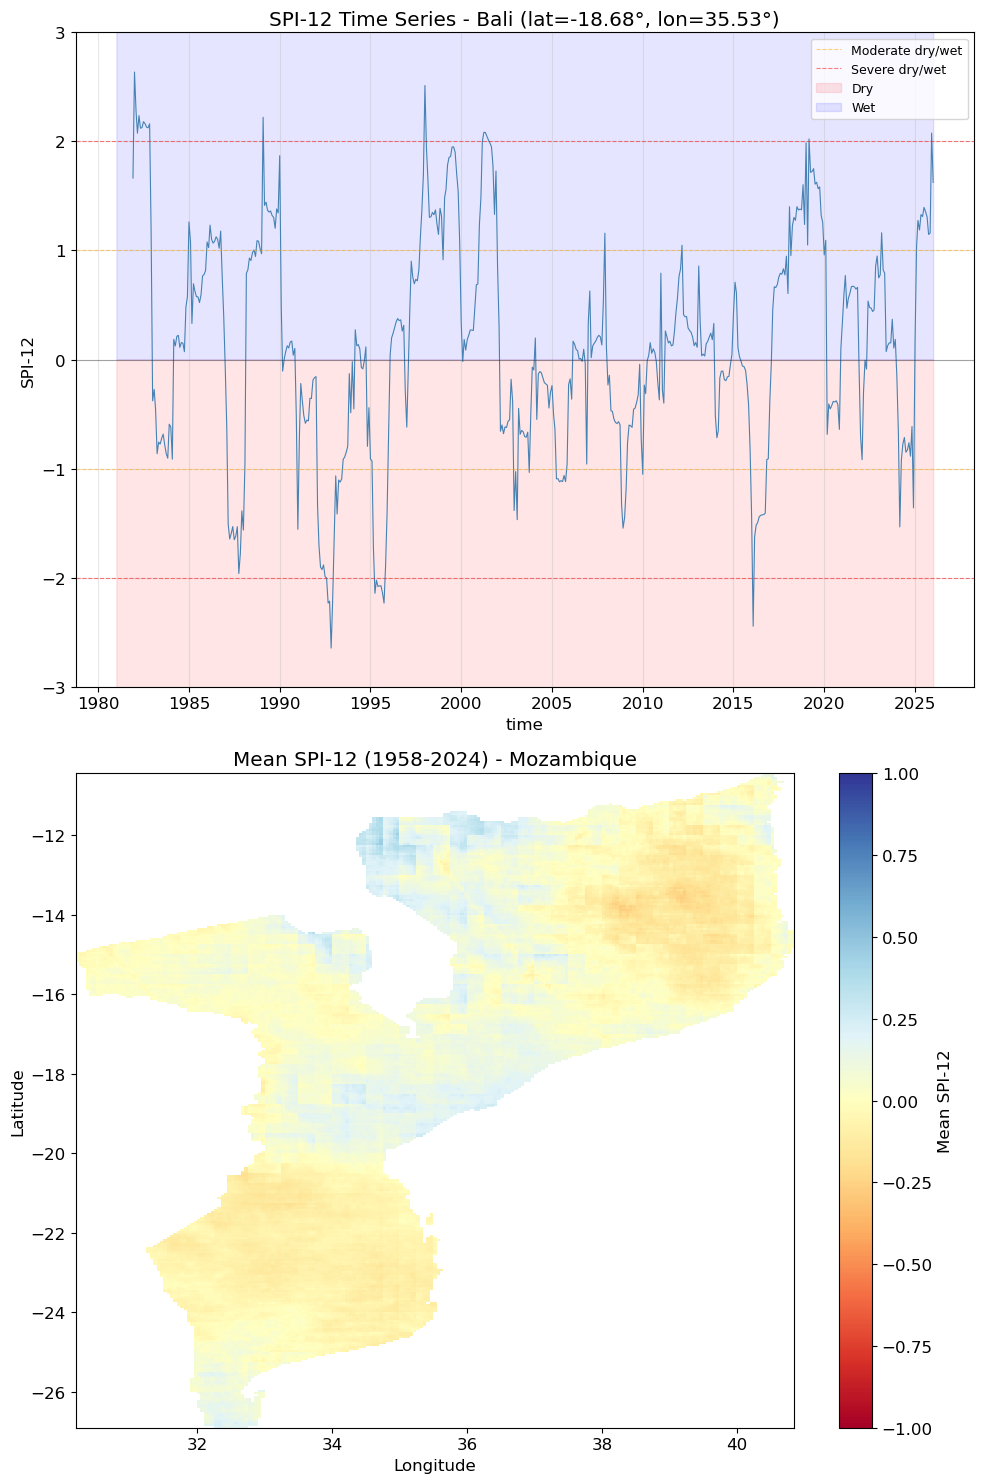

In [16]:
ig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 15))

# Time series at sample point
spi_12[:, sample_lat_idx, sample_lon_idx].plot(ax=ax1, linewidth=0.8, color='steelblue') # SPI at the sample point
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.3)
ax1.axhline(y=-1.0, color='orange', linestyle='--', linewidth=0.8, alpha=0.5, label='Moderate dry/wet')
ax1.axhline(y=-2.0, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Severe dry/wet')
ax1.axhline(y=1.0, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.axhline(y=2.0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.fill_between(spi_12.time, -10, 0, alpha=0.1, color='red', label='Dry')
ax1.fill_between(spi_12.time, 0, 10, alpha=0.1, color='blue', label='Wet')
ax1.set_title(f'SPI-12 Time Series - Bali (lat={float(precip.lat[sample_lat_idx]):.2f}°, lon={float(precip.lon[sample_lon_idx]):.2f}°)')
ax1.set_ylabel('SPI-12')
ax1.set_ylim(-3, 3)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=9)

# Spatial pattern (mean over time) # patial mean SPI over the whole domain
spi_12.mean(dim='time').plot(ax=ax2, cmap='RdYlBu', vmin=-1, vmax=1, 
                              cbar_kwargs={'label': 'Mean SPI-12'})
ax2.set_title('Mean SPI-12 (1958-2024) - Mozambique')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

## **Save Fitting Parameters for Reuse**

In [17]:
# Gamma fitting parameters can be saved and reused to speed up 
# calculations on new data with the same calibration period.
param_file = output_dir + 'spi_gamma_params_12_month_bali.nc'

save_fitting_params(
    params,
    param_file,
    scale=12,
    periodicity='monthly',
    index_type='spi',
    calibration_start_year=calib_start,
    calibration_end_year=calib_end,
    coords={'lat': precip.lat, 'lon': precip.lon}
)

print(f"✓ Parameters saved to: {param_file}")

# Load parameters
loaded_params = load_fitting_params(param_file, scale=12, periodicity='monthly')
print(f"✓ Parameters loaded successfully")
print(f"  Alpha shape: {loaded_params['alpha'].shape}")
print(f"  Beta shape: {loaded_params['beta'].shape}")
print(f"  Prob_zero shape: {loaded_params['prob_zero'].shape}")

2026-03-16 22:40:00 | INFO     | indices | Saving gamma fitting parameters to: ../output/netcdf/spi_gamma_params_12_month_bali.nc
2026-03-16 22:40:00 | INFO     | indices | Fitting parameters saved: ../output/netcdf/spi_gamma_params_12_month_bali.nc
2026-03-16 22:40:00 | INFO     | indices | Loading fitting parameters from: ../output/netcdf/spi_gamma_params_12_month_bali.nc
2026-03-16 22:40:00 | INFO     | indices | Loaded gamma parameters for scale=12, periodicity=monthly, shape=(12, 329, 213)


✓ Parameters saved to: ../output/netcdf/spi_gamma_params_12_month_bali.nc
✓ Parameters loaded successfully
  Alpha shape: (12, 329, 213)
  Beta shape: (12, 329, 213)
  Prob_zero shape: (12, 329, 213)


In [18]:
## Use Pre-Computed Parameter on 'new' samples
print("Calculating SPI-12 with pre-computed parameters...")

spi_12_fast = spi(
    precip, # the new data
    scale=12,
    periodicity='monthly',
    fitting_params=loaded_params # load parameters
)

print("✓ Calculation complete!")

# Verify results are identical
diff = np.abs(spi_12.values - spi_12_fast.values)
max_diff = np.nanmax(diff)
print(f"  Max difference from original: {max_diff:.10f}")
print("  Results are identical!" if max_diff < 1e-6 else "  Warning: Results differ!")

2026-03-16 22:41:56 | INFO     | indices | Computing SPI-12 (distribution=gamma)
2026-03-16 22:41:56 | INFO     | indices | Input shape: (541, 329, 213), dims: ('time', 'lat', 'lon'), data_start_year: 1981
2026-03-16 22:41:56 | INFO     | compute | Computing index: shape=(541, 329, 213), scale=12, distribution=gamma, grid_cells=70,077
2026-03-16 22:41:56 | INFO     | compute | Data has 541 timesteps (not divisible by 12). Padding 11 NaN timesteps to complete final year (46 years total).
2026-03-16 22:41:56 | INFO     | compute | Step 1/3: Applying temporal scaling...


Calculating SPI-12 with pre-computed parameters...


2026-03-16 22:41:57 | INFO     | compute | Step 2/3: Computing gamma parameters...
2026-03-16 22:41:57 | INFO     | compute | Using pre-computed fitting parameters
2026-03-16 22:41:57 | INFO     | compute | Step 3/3: Transforming to standard normal...
2026-03-16 22:42:02 | INFO     | compute | Index computation complete
2026-03-16 22:42:02 | INFO     | indices | SPI-12 computation complete. Output shape: (541, 329, 213)


✓ Calculation complete!
  Max difference from original: 0.0000000000
  Results are identical!


## **Calculate SPI for Multiple Time Scales**

Different time scales capture different types of climate extremes:
- **SPI-1**: Short-term meteorological (precipitation deficit/excess)
- **SPI-3**: Seasonal agricultural (crop water stress/flooding)
- **SPI-6**: Medium-term hydrological (reservoir/groundwater)
- **SPI-12**: Long-term water resources (multi-year planning)

In [19]:
# Calculate multiple scales
print("Calculating SPI for scales: 1, 3, 6, 12 months...")

spi_multi = spi_multi_scale( #Save distribution fitting parameters to NetCDF file for later reuse
    precip,
    scales=[1, 3, 6, 12],
    periodicity='monthly',
    calibration_start_year=calib_start,
    calibration_end_year=calib_end
)

print("✓ Multi-scale SPI calculation complete!")
print(f"  Variables: {list(spi_multi.data_vars)}")

2026-03-16 22:43:37 | INFO     | indices | Computing SPI for scales: [1, 3, 6, 12] (distribution=gamma)
2026-03-16 22:43:37 | INFO     | indices | Processing scale 1...
2026-03-16 22:43:37 | INFO     | indices | Computing SPI-1 (distribution=gamma)
2026-03-16 22:43:37 | INFO     | indices | Input shape: (541, 329, 213), dims: ('time', 'lat', 'lon'), data_start_year: 1981
2026-03-16 22:43:37 | INFO     | compute | Computing index: shape=(541, 329, 213), scale=1, distribution=gamma, grid_cells=70,077
2026-03-16 22:43:37 | INFO     | compute | Data has 541 timesteps (not divisible by 12). Padding 11 NaN timesteps to complete final year (46 years total).
2026-03-16 22:43:37 | INFO     | compute | Step 1/3: Applying temporal scaling...
2026-03-16 22:43:37 | INFO     | compute | Step 2/3: Computing gamma parameters...


Calculating SPI for scales: 1, 3, 6, 12 months...


2026-03-16 22:43:38 | INFO     | compute | Step 3/3: Transforming to standard normal...
2026-03-16 22:43:43 | INFO     | compute | Index computation complete
2026-03-16 22:43:43 | INFO     | indices | SPI-1 computation complete. Output shape: (541, 329, 213)
2026-03-16 22:43:43 | INFO     | indices | Processing scale 3...
2026-03-16 22:43:43 | INFO     | indices | Computing SPI-3 (distribution=gamma)
2026-03-16 22:43:43 | INFO     | indices | Input shape: (541, 329, 213), dims: ('time', 'lat', 'lon'), data_start_year: 1981
2026-03-16 22:43:43 | INFO     | compute | Computing index: shape=(541, 329, 213), scale=3, distribution=gamma, grid_cells=70,077
2026-03-16 22:43:43 | INFO     | compute | Data has 541 timesteps (not divisible by 12). Padding 11 NaN timesteps to complete final year (46 years total).
2026-03-16 22:43:43 | INFO     | compute | Step 1/3: Applying temporal scaling...
2026-03-16 22:43:44 | INFO     | compute | Step 2/3: Computing gamma parameters...
2026-03-16 22:43:44 |

✓ Multi-scale SPI calculation complete!
  Variables: ['spi_gamma_1_month', 'spi_gamma_3_month', 'spi_gamma_6_month', 'spi_gamma_12_month']


## **Compare Different Time Scales**

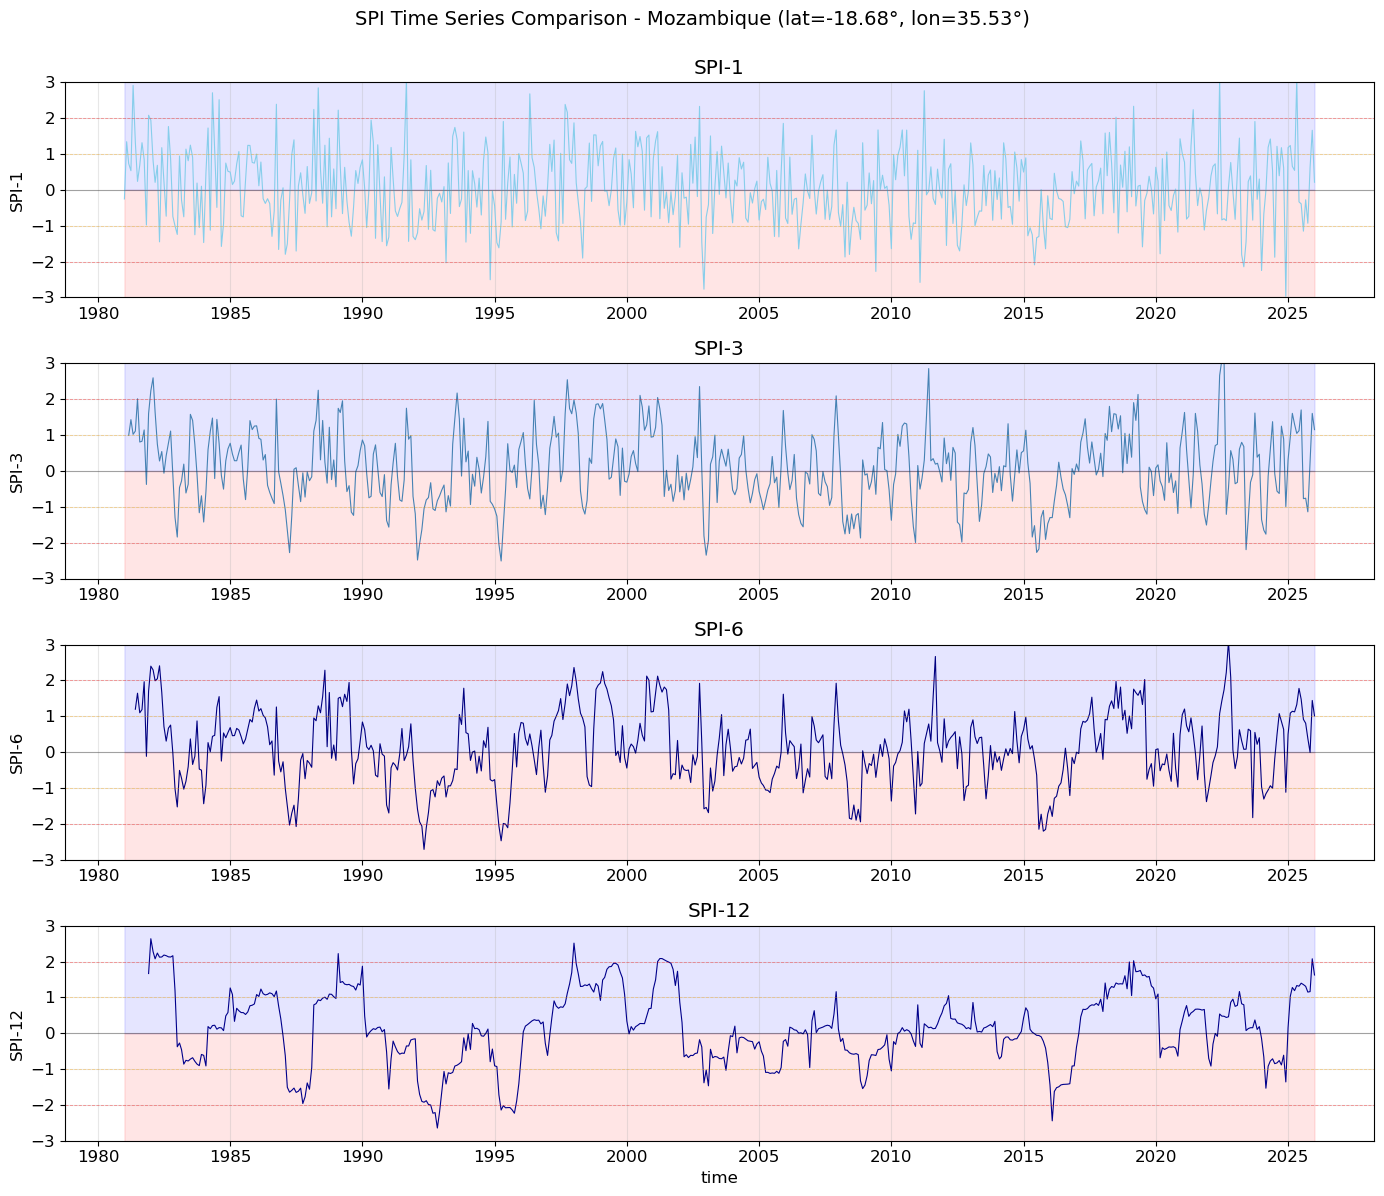


Observations:
  - SPI-1 shows high frequency variability (month-to-month)
  - SPI-12 shows smoother, longer-term trends
  - Extreme events persist longer at longer time scales


In [21]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
# at a single sample point
scales = [1, 3, 6, 12]
colors = ['skyblue', 'steelblue', 'navy', 'darkblue']

for i, (scale, color) in enumerate(zip(scales, colors)):
    var_name = f'spi_gamma_{scale}_month'
    spi_data = spi_multi[var_name]
    
    # Plot time series 
    spi_data[:, sample_lat_idx, sample_lon_idx].plot(
        ax=axes[i], 
        linewidth=0.8, 
        color=color
    )
    
    # Add reference lines
    axes[i].axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.3)
    axes[i].axhline(y=-1.0, color='orange', linestyle='--', linewidth=0.6, alpha=0.4)
    axes[i].axhline(y=-2.0, color='red', linestyle='--', linewidth=0.6, alpha=0.4)
    axes[i].axhline(y=1.0, color='orange', linestyle='--', linewidth=0.6, alpha=0.4)
    axes[i].axhline(y=2.0, color='red', linestyle='--', linewidth=0.6, alpha=0.4)
    axes[i].fill_between(spi_data.time, -10, 0, alpha=0.1, color='red')
    axes[i].fill_between(spi_data.time, 0, 10, alpha=0.1, color='blue')
    
    axes[i].set_title(f'SPI-{scale}')
    axes[i].set_ylabel(f'SPI-{scale}')
    axes[i].set_ylim(-3, 3)
    axes[i].grid(True, alpha=0.3)
    
    if i < 3:
        axes[i].set_xlabel('')

plt.suptitle(f'SPI Time Series Comparison - Mozambique (lat={float(precip.lat[sample_lat_idx]):.2f}°, lon={float(precip.lon[sample_lon_idx]):.2f}°)', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("  - SPI-1 shows high frequency variability (month-to-month)")
print("  - SPI-12 shows smoother, longer-term trends")
print("  - Extreme events persist longer at longer time scales")

## **Climate Extremes Classification**

In [23]:
# Display SPI-12 classification scheme - Foe the whole region
print("SPI-12 Classification (11 Categories):")
print("=" * 60)
print("  -2.00 and below    : Exceptionally dry")
print("  -2.00 to -1.50     : Extremely dry")
print("  -1.50 to -1.20     : Severely dry")
print("  -1.20 to -0.70     : Moderately dry")
print("  -0.70 to -0.50     : Abnormally dry")
print("  -0.50 to +0.50     : Near normal")
print("  +0.50 to +0.70     : Abnormally moist")
print("  +0.70 to +1.20     : Moderately moist")
print("  +1.20 to +1.50     : Very moist")
print("  +1.50 to +2.00     : Extremely moist")
print("  +2.00 and above    : Exceptionally moist")
print()

# Count occurrences by category
print("Frequency Distribution (Moz, 1958-2024):")
print("=" * 60)

# Define boundaries
bounds = [-3.0, -2.0, -1.5, -1.2, -0.7, -0.5, 0.5, 0.7, 1.2, 1.5, 2.0, 3.0]
categories = [
    'Exceptionally dry',
    'Extremely dry',
    'Severely dry',
    'Moderately dry',
    'Abnormally dry',
    'Near normal',
    'Abnormally moist',
    'Moderately moist',
    'Very moist',
    'Extremely moist',
    'Exceptionally moist'
]

# Count values in each category
valid_values = spi_12.values[~np.isnan(spi_12.values)]
total_count = len(valid_values)

for i in range(len(bounds) - 1):
    lower = bounds[i]
    upper = bounds[i + 1]
    
    if i == 0:  # First category (below -2.0)
        count = np.sum(valid_values <= upper)
    elif i == len(bounds) - 2:  # Last category (above +2.0)
        count = np.sum(valid_values > lower)
    else:
        count = np.sum((valid_values > lower) & (valid_values <= upper))
    
    pct = 100 * count / total_count
    print(f"  {categories[i]:20s}: {count:6d} ({pct:5.1f}%)")

SPI-12 Classification (11 Categories):
  -2.00 and below    : Exceptionally dry
  -2.00 to -1.50     : Extremely dry
  -1.50 to -1.20     : Severely dry
  -1.20 to -0.70     : Moderately dry
  -0.70 to -0.50     : Abnormally dry
  -0.50 to +0.50     : Near normal
  +0.50 to +0.70     : Abnormally moist
  +0.70 to +1.20     : Moderately moist
  +1.20 to +1.50     : Very moist
  +1.50 to +2.00     : Extremely moist
  +2.00 and above    : Exceptionally moist

Frequency Distribution (Moz, 1958-2024):
  Exceptionally dry   : 368997 (  2.5%)
  Extremely dry       : 649410 (  4.4%)
  Severely dry        : 669611 (  4.6%)
  Moderately dry      : 1774249 ( 12.1%)
  Abnormally dry      : 990471 (  6.7%)
  Near normal         : 5618019 ( 38.2%)
  Abnormally moist    : 975073 (  6.6%)
  Moderately moist    : 1883579 ( 12.8%)
  Very moist          : 728773 (  5.0%)
  Extremely moist     : 663171 (  4.5%)
  Exceptionally moist : 383497 (  2.6%)


## **Visualize the climate extremes categories**

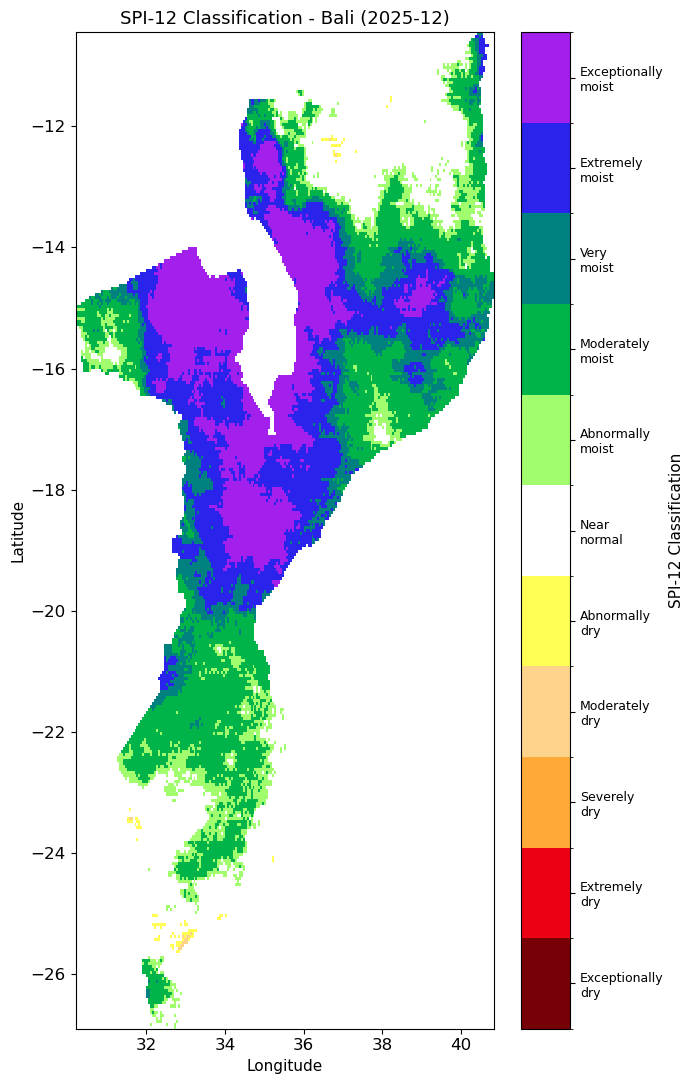

In [31]:
# Plots climate extremes category map for the latest month
# for each grid point
time_idx = -2  # Latest month (Dec 2024)

fig, ax = plt.subplots(figsize=(7, 11))

# Custom colormap for climate extremes categories (WMO-style colors)
from matplotlib.colors import ListedColormap, BoundaryNorm

# SPI classification colors (11 categories)
colors = [
    '#760005',  # Exceptionally dry: -2.00 and below
    '#ec0013',  # Extremely dry: -2.00 to -1.50
    '#ffa938',  # Severely dry: -1.50 to -1.20
    '#fdd28a',  # Moderately dry: -1.20 to -0.70
    '#fefe53',  # Abnormally dry: -0.70 to -0.50
    '#ffffff',  # Near normal: -0.50 to +0.50
    '#a2fd6e',  # Abnormally moist: +0.50 to +0.70
    '#00b44a',  # Moderately moist: +0.70 to +1.20
    '#008180',  # Very moist: +1.20 to +1.50
    '#2a23eb',  # Extremely moist: +1.50 to +2.00
    '#a21fec'   # Exceptionally moist: +2.00 and above
]

# Define boundaries for 11 categories
bounds = [-3.0, -2.0, -1.5, -1.2, -0.7, -0.5, 0.5, 0.7, 1.2, 1.5, 2.0, 3.0]
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

# Extract data for plotting
spi_data = spi_12.isel(time=time_idx)

# Create meshgrid for pcolormesh
lon_2d, lat_2d = np.meshgrid(spi_12.lon.values, spi_12.lat.values)

# Plot using pcolormesh
im = ax.pcolormesh(
    lon_2d,
    lat_2d,
    spi_data.values,  # Use SPI values directly for fine-grained classification
    cmap=cmap,
    norm=norm,
    shading='auto'
)

# Colorbar with all 11 categories
cbar = plt.colorbar(im, ax=ax, ticks=[-2.5, -1.75, -1.35, -0.95, -0.6, 0, 0.6, 0.95, 1.35, 1.75, 2.5])
cbar.set_label('SPI-12 Classification', fontsize=11)
cbar.ax.set_yticklabels([
    'Exceptionally\ndry',
    'Extremely\ndry', 
    'Severely\ndry',
    'Moderately\ndry',
    'Abnormally\ndry',
    'Near\nnormal',
    'Abnormally\nmoist',
    'Moderately\nmoist',
    'Very\nmoist',
    'Extremely\nmoist',
    'Exceptionally\nmoist'
], fontsize=9)

ax.set_title(f'SPI-12 Classification - Bali ({str(spi_12.time[time_idx].values)[:7]})', fontsize=13)
ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)

plt.tight_layout()
plt.show()

## **Area Percentage Analysis**
Calculate the percentage of area experiencing dry or wet conditions over time

In [32]:
# Calculate dry area percentage time series
# Threshold -1.0 = moderate dry or worse
dry_pct = get_drought_area_percentage(spi_12, threshold=-1.0)

# Calculate wet area percentage time series  
# For wet events, we need to invert the logic
wet_pct = 100 * (spi_12 >= 1.0).sum(dim=['lat', 'lon']) / (spi_12.sizes['lat'] * spi_12.sizes['lon'])

print(f"Dry Area Statistics (SPI <= -1.0):")
print(f"  Mean: {float(dry_pct.mean()):.1f}%")
print(f"  Max: {float(dry_pct.max()):.1f}%")
print(f"  Min: {float(dry_pct.min()):.1f}%")

print(f"\nWet Area Statistics (SPI >= +1.0):")
print(f"  Mean: {float(wet_pct.mean()):.1f}%")
print(f"  Max: {float(wet_pct.max()):.1f}%")
print(f"  Min: {float(wet_pct.min()):.1f}%")

Dry Area Statistics (SPI <= -1.0):
  Mean: 15.5%
  Max: 70.1%
  Min: 0.0%

Wet Area Statistics (SPI >= +1.0):
  Mean: 6.4%
  Max: 28.0%
  Min: 0.0%


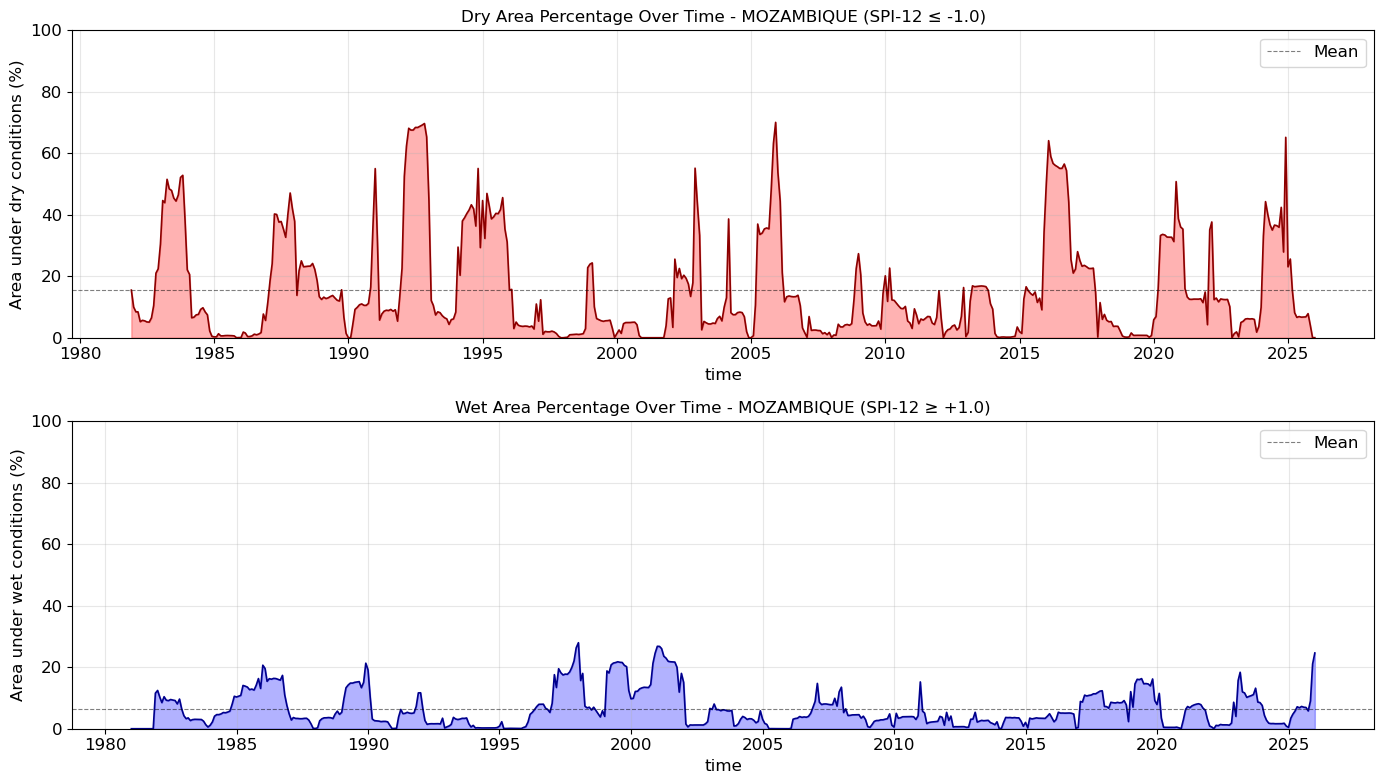

In [35]:
#Plot dry and wet area percentages over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Dry area
dry_pct.plot(ax=ax1, linewidth=1.2, color='darkred')
ax1.axhline(y=dry_pct.mean(), color='k', linestyle='--', linewidth=0.8, alpha=0.5, label='Mean')
ax1.fill_between(dry_pct.time, 0, dry_pct, alpha=0.3, color='red')
ax1.set_title('Dry Area Percentage Over Time - MOZAMBIQUE (SPI-12 ≤ -1.0)', fontsize=12)
ax1.set_ylabel('Area under dry conditions (%)')
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Wet area
wet_pct.plot(ax=ax2, linewidth=1.2, color='darkblue')
ax2.axhline(y=wet_pct.mean(), color='k', linestyle='--', linewidth=0.8, alpha=0.5, label='Mean')
ax2.fill_between(wet_pct.time, 0, wet_pct, alpha=0.3, color='blue')
ax2.set_title('Wet Area Percentage Over Time - MOZAMBIQUE (SPI-12 ≥ +1.0)', fontsize=12)
ax2.set_ylabel('Area under wet conditions (%)')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

**SPI** is a **standardized index** built **from accumulated precipitation at a chosen time scale (e.g., 1, 3, 6, 12 months)**. For each location and timescale you:
- **Build a long historical series of precipitation sums at that timescale (e.g., rolling 3-month totals (*calculate the cumulative sum of data for the current month and the two preceding months*) for each month)**
- **Fit a probability distribution to those historical sums** (*commonly the gamma distribution; alternatives exist where gamma is inadequate*).
- **Convert the cumulative probability for a given observed (or forecasted) precipitation total into the standard normal space** (so **SPI has mean ≈ 0 and std ≈ 1**). SPI thresholds (e.g., **SPI ≤ −1 = moderate drought**) are then used operationally

In [ ]:
Rainfall forcasting applied to seasonal Drought monitoring.